# NB6 — Đánh giá chuẩn (benchmark) SFT vs SFT+DPO bằng lm-eval (TUỲ CHỌN, thưởng điểm)

**Công nghệ:** `lm-eval` 0.4.13 trên mô hình 16-bit: `models/sft-merged` (SFT) và
`models/sft-merged` + `peft=adapters/dpo` (SFT+DPO).

Ba lỗi của bản cũ đã sửa:
1. **Chat template.** Mô hình chat bị chấm như mô hình base (không template) thì điểm
   IFEval/GSM8K không phản ánh cách nó được dùng. Ở đây truyền `--apply_chat_template`
   và `--fewshot_as_multiturn`.
2. **`--limit` tính theo từng subtask.** `--limit 500` trên nhóm `mmlu` (57 môn) là
   ~28k câu, không phải 500. Limit MMLU ở đây được đặt *theo môn*.
3. **AlpacaEval-lite bị bỏ.** `tatsu-lab/alpaca_eval` là bộ dữ liệu dạng script, không
   nạp được với `datasets` ≥ 4. Đánh giá theo kiểu giám khảo đã có ở NB4.

Thêm `global_mmlu_full_vi` (MMLU dịch tiếng Việt, có kiểm duyệt) vì lab là tiếng Việt.

> Điểm có thể **giảm** sau DPO (alignment tax, tức thuế căn chỉnh). Với limit nhỏ, chênh lệch ±2–3 điểm
> thường nằm trong nhiễu: xem cột `stderr` trước khi kết luận.

In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "lab22" / "config.py").exists())
sys.path.insert(0, str(ROOT))

import torch

from lab22 import config as C

assert torch.cuda.is_available()
assert C.SFT_MERGED.exists() and C.DPO_ADAPTER.exists(), "Run NB1 + NB3 first"
C.ensure_dirs()

BIG = C.COMPUTE_TIER == "BIGGPU"
# name: (task, num_fewshot, limit per subtask or None for all, primary metric)
BENCHMARKS = {
    "IFEval": ("ifeval", 0, None if BIG else 200, "prompt_level_strict_acc,none"),
    "GSM8K": ("gsm8k", 5, None if BIG else 250, "exact_match,flexible-extract"),
    "Global-MMLU-vi": ("global_mmlu_full_vi", 0, 40 if BIG else 10, "acc,none"),
}
DTYPE = "float16"
BATCH = os.environ.get("BENCH_BATCH_SIZE", "auto" if BIG else "1")
for name, (task, shots, limit, _metric) in BENCHMARKS.items():
    print(f"{name:15s} task={task} fewshot={shots} limit/subtask={limit or 'all'}")

IFEval          task=ifeval fewshot=0 limit/subtask=200
GSM8K           task=gsm8k fewshot=5 limit/subtask=250
Global-MMLU-vi  task=global_mmlu_full_vi fewshot=0 limit/subtask=10


## 1. Hàm chạy lm-eval

In [2]:
def run_lm_eval(label: str, task: str, shots: int, limit: int | None) -> dict:
    model_args = f"pretrained={C.SFT_MERGED},dtype={DTYPE},enable_thinking=False"
    if label == "dpo":
        model_args += f",peft={C.DPO_ADAPTER}"
    out_dir = C.EVAL_DIR / "lm_eval" / f"{label}-{task}"
    # Resume at completed evaluation boundaries, including results from older runs.
    # Require the same model paths, task, limit, few-shot count and chat template.
    metric = next(v[3] for v in BENCHMARKS.values() if v[0] == task)
    for saved in sorted(out_dir.glob("**/results*.json"), key=lambda p: p.stat().st_mtime, reverse=True):
        try:
            cached = json.loads(saved.read_text(encoding="utf-8"))
            cfg = cached.get("config", {})
            task_cfg = cached.get("configs", {})
            matching_tasks = [v for k, v in task_cfg.items() if k == task or k.startswith(task + "_")]
            shot_counts = [v.get("num_fewshot", 0) for v in matching_tasks]
            args_match = cfg.get("model_args") == model_args
            if isinstance(cfg.get("model_args"), dict):
                wanted = dict(item.split("=", 1) for item in model_args.split(","))
                args_match = all(str(cfg["model_args"].get(k)) == v for k, v in wanted.items())
                args_match = args_match and (label == "dpo" or not cfg["model_args"].get("peft"))
            if (args_match and cfg.get("limit") == limit and cfg.get("apply_chat_template")
                    and shot_counts and all(n == shots for n in shot_counts)):
                score(cached, task, metric)  # reject incomplete results
                print(f"RESUME: giữ kết quả {label}/{task}: {saved}", flush=True)
                return cached
        except (ValueError, KeyError, TypeError):
            continue
    cmd = [
        "lm_eval", "--model", "hf", "--model_args", model_args,
        "--tasks", task, "--num_fewshot", str(shots),
        "--apply_chat_template", "--batch_size", BATCH,
        "--device", "cuda:0", "--seed", str(C.SEED), "--output_path", str(out_dir),
    ]
    if shots:
        cmd.append("--fewshot_as_multiturn")
    if limit:
        cmd += ["--limit", str(limit)]
    print(f"\n>>> {label} · {task}\n{' '.join(cmd)}")
    proc = subprocess.run(cmd, capture_output=True, text=True)
    files = sorted(out_dir.glob("**/results*.json"), key=lambda p: p.stat().st_mtime)
    if proc.returncode != 0 or not files:
        print(proc.stderr[-2000:])
        raise RuntimeError(f"lm_eval failed for {label}/{task}")
    return json.loads(files[-1].read_text())


def score(result: dict, task: str, metric: str) -> tuple[float, float]:
    # Groups (global_mmlu_full_vi) report the aggregate under the group name.
    block = result.get("groups", {}).get(task) or result["results"][task]
    stderr_key = metric.replace(",", "_stderr,", 1)
    return float(block[metric]), float(block.get(stderr_key, float("nan")))

## 2. Chạy (T4: ~40–60 phút cho cả hai điều kiện)

In [3]:
rows = []
for name, (task, shots, limit, metric) in BENCHMARKS.items():
    row = {"benchmark": name, "task": task, "limit_per_subtask": limit}
    for label in ("sft", "dpo"):
        value, err = score(run_lm_eval(label, task, shots, limit), task, metric)
        row[label], row[f"{label}_stderr"] = value, err
    row["delta"] = row["dpo"] - row["sft"]
    rows.append(row)
    (C.EVAL_DIR / "benchmark_progress.json").write_text(
        json.dumps({"compute_tier": C.COMPUTE_TIER, "results": rows}, indent=2), encoding="utf-8"
    )
    print(row)


>>> sft · ifeval
lm_eval --model hf --model_args pretrained=/kaggle/temp/lab22-runtime/models/sft-merged,dtype=float16,enable_thinking=False --tasks ifeval --num_fewshot 0 --apply_chat_template --batch_size 1 --device cuda:0 --seed 42 --output_path /kaggle/working/lab22/data/eval/lm_eval/sft-ifeval --limit 200



>>> dpo · ifeval
lm_eval --model hf --model_args pretrained=/kaggle/temp/lab22-runtime/models/sft-merged,dtype=float16,enable_thinking=False,peft=/kaggle/working/lab22/adapters/dpo --tasks ifeval --num_fewshot 0 --apply_chat_template --batch_size 1 --device cuda:0 --seed 42 --output_path /kaggle/working/lab22/data/eval/lm_eval/dpo-ifeval --limit 200


{'benchmark': 'IFEval', 'task': 'ifeval', 'limit_per_subtask': 200, 'sft': 0.505, 'sft_stderr': 0.035442288003096976, 'dpo': 0.525, 'dpo_stderr': 0.03539972744976418, 'delta': 0.020000000000000018}

>>> sft · gsm8k
lm_eval --model hf --model_args pretrained=/kaggle/temp/lab22-runtime/models/sft-merged,dtype=float16,enable_thinking=False --tasks gsm8k --num_fewshot 5 --apply_chat_template --batch_size 1 --device cuda:0 --seed 42 --output_path /kaggle/working/lab22/data/eval/lm_eval/sft-gsm8k --fewshot_as_multiturn --limit 250



>>> dpo · gsm8k
lm_eval --model hf --model_args pretrained=/kaggle/temp/lab22-runtime/models/sft-merged,dtype=float16,enable_thinking=False,peft=/kaggle/working/lab22/adapters/dpo --tasks gsm8k --num_fewshot 5 --apply_chat_template --batch_size 1 --device cuda:0 --seed 42 --output_path /kaggle/working/lab22/data/eval/lm_eval/dpo-gsm8k --fewshot_as_multiturn --limit 250


{'benchmark': 'GSM8K', 'task': 'gsm8k', 'limit_per_subtask': 250, 'sft': 0.82, 'sft_stderr': 0.02434689065029353, 'dpo': 0.828, 'dpo_stderr': 0.023915513944486218, 'delta': 0.008000000000000007}

>>> sft · global_mmlu_full_vi
lm_eval --model hf --model_args pretrained=/kaggle/temp/lab22-runtime/models/sft-merged,dtype=float16,enable_thinking=False --tasks global_mmlu_full_vi --num_fewshot 0 --apply_chat_template --batch_size 1 --device cuda:0 --seed 42 --output_path /kaggle/working/lab22/data/eval/lm_eval/sft-global_mmlu_full_vi --limit 10



>>> dpo · global_mmlu_full_vi
lm_eval --model hf --model_args pretrained=/kaggle/temp/lab22-runtime/models/sft-merged,dtype=float16,enable_thinking=False,peft=/kaggle/working/lab22/adapters/dpo --tasks global_mmlu_full_vi --num_fewshot 0 --apply_chat_template --batch_size 1 --device cuda:0 --seed 42 --output_path /kaggle/working/lab22/data/eval/lm_eval/dpo-global_mmlu_full_vi --limit 10


{'benchmark': 'Global-MMLU-vi', 'task': 'global_mmlu_full_vi', 'limit_per_subtask': 10, 'sft': 0.24385964912280703, 'sft_stderr': 0.017881736668328253, 'dpo': 0.24385964912280703, 'dpo_stderr': 0.017881736668328253, 'delta': 0.0}


## 3. Biểu đồ (sản phẩm nộp `07-benchmark-comparison.png`)

     benchmark                task  limit_per_subtask     sft  sft_stderr     dpo  dpo_stderr  delta
        IFEval              ifeval                200 0.50500    0.035442 0.52500    0.035400  0.020
         GSM8K               gsm8k                250 0.82000    0.024347 0.82800    0.023916  0.008
Global-MMLU-vi global_mmlu_full_vi                 10 0.24386    0.017882 0.24386    0.017882  0.000


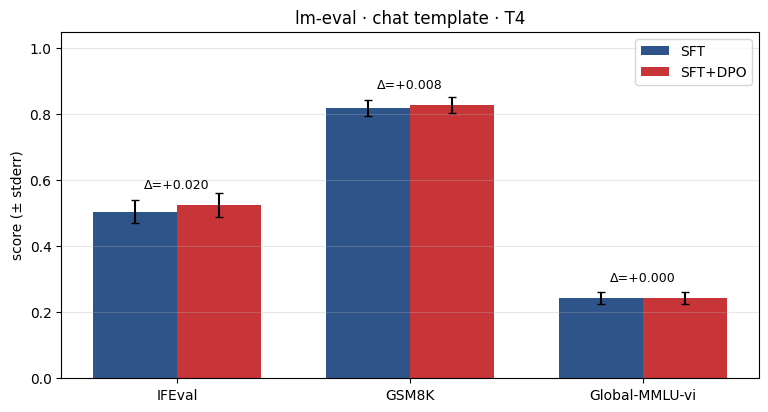

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.DataFrame(rows)
print(df.to_string(index=False))

x = np.arange(len(df))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - 0.18, df["sft"], 0.36, yerr=df["sft_stderr"], label="SFT", color="#2e548a", capsize=3)
ax.bar(x + 0.18, df["dpo"], 0.36, yerr=df["dpo_stderr"], label="SFT+DPO", color="#c83538", capsize=3)
for i, r in df.iterrows():
    ax.annotate(f"Δ={r['delta']:+.3f}", (x[i], max(r["sft"], r["dpo"]) + 0.05), ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(df["benchmark"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("score (± stderr)")
ax.set_title(f"lm-eval · chat template · {C.COMPUTE_TIER}")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.savefig(C.SCREENSHOTS / "07-benchmark-comparison.png", dpi=120, bbox_inches="tight")
plt.show()

In [5]:
(C.EVAL_DIR / "benchmark_results.json").write_text(
    json.dumps({"compute_tier": C.COMPUTE_TIER, "dtype": DTYPE, "chat_template": True, "results": rows}, indent=2)
)
print("Saved data/eval/benchmark_results.json")

Saved data/eval/benchmark_results.json


## 4. Đọc kết quả (REFLECTION §7)

1. |Δ| có lớn hơn ~2× stderr không? Nếu không, đừng gọi là "tăng" hay "giảm".
2. IFEval đo khả năng làm đúng định dạng: DPO trên dữ liệu chat thường giúp hoặc giữ nguyên.
3. GSM8K giảm ⇒ alignment tax (thuế căn chỉnh); NB7 (GRPO với reward kiểm chứng được) là một cách lấy lại.
4. Global-MMLU-vi gần như phẳng là bình thường: DPO không dạy kiến thức mới.

**Tiếp theo:** NB7 (GRPO, thưởng điểm) hoặc `make verify`.